# XGBoost Algorithm in Machine Learning

Traditional models like decision trees and random forests are easy to interpret but may lack accuracy on complex data. XGBoost (eXtreme Gradient Boosting) is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model.

- It uses decision trees as base learners, building them sequentially so each tree corrects errors from the previous one and it is known as boosting.
- It features parallel processing for faster training on large datasets and allows parameter customization to optimize performance for specific problems.

In [1]:
# ==========================================
# 1. IMPORT LIBRARIES & SETUP ENVIRONMENT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Ensure matplotlib plots render correctly inside Jupyter/Colab notebooks
%matplotlib inline

# Set a clean visual theme for the Seaborn plots
sns.set_style("whitegrid")

In [9]:
# ==========================================
# 2. DATA LOADING & EXPLORATION
# ==========================================

# Load the dataset into a pandas DataFrame
df = pd.read_csv("../data/customers.csv")

# Preview the first 5 rows to inspect columns and data structure
df.head()

# Display central tendency, dispersion, and shape of the dataset's distribution
print("\nStatistical Summary")
display(df.describe())


Statistical Summary


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [3]:
# ==========================================
# 3. DATA PREPROCESSING & SPLITTING
# ==========================================

# Features (X): Drop the target column 'Channel'
X = df.drop('Channel', axis=1)

# Target (y): Map 'Channel' values to binary (1 -> 1, 2 -> 0) for the binary classifier
y = df['Channel'].map({1: 1, 2: 0})

# Split data into training (70%) and testing (30%) sets
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
# ==========================================
# 4. MODEL INITIALIZATION & TRAINING
# ==========================================

# Define hyperparameters for the XGBoost Classifier
params = {
    'objective': 'binary:logistic',  # Configures the model for binary classification
    'max_depth': 4,                  # Limits tree depth to control overfitting
    'learning_rate': 0.1,            # Step size shrinkage used to prevent overfitting
    'n_estimators': 100,             # Number of boosting rounds (trees to build)
    'alpha': 10                      # L1 regularization term on weights
}

# Instantiate the model with the defined hyperparameters
model = XGBClassifier(**params)

# Train the model on the training data
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [5]:
# ==========================================
# 5. MODEL EVALUATION
# ==========================================

# Generate predictions on the unseen test set
y_pred = model.predict(X_test)

# Calculate and print overall classification accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Print a detailed report containing Precision, Recall, and F1-Score per class
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9090909090909091

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.92      0.85        38
           1       0.97      0.90      0.93        94

    accuracy                           0.91       132
   macro avg       0.88      0.91      0.89       132
weighted avg       0.92      0.91      0.91       132



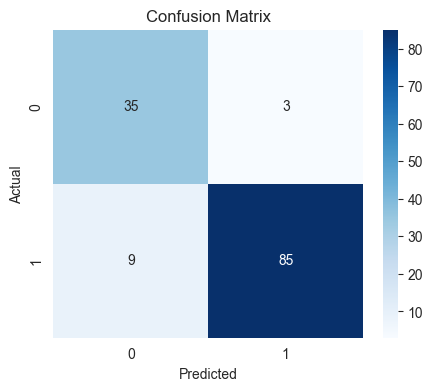

<Figure size 800x600 with 0 Axes>

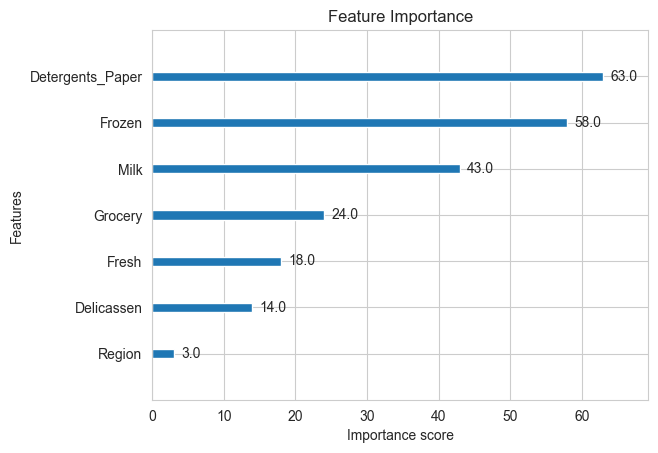

/Users/nasir/dev/applied-data/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

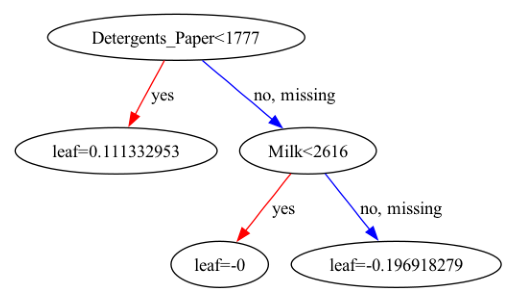

In [6]:
# ==========================================
# 6. VISUALIZATIONS
# ==========================================

# --- Plot 1: Confusion Matrix ---
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
# annot=True shows counts, fmt='d' forces integer format, cmap='Blues' sets color scheme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- Plot 2: Feature Importance ---
plt.figure(figsize=(8, 6))
# Built-in XGBoost function to plot how much each feature contributed to the model
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

# --- Plot 3: Decision Tree Structure ---
plt.figure(figsize=(20, 10))
# Visualizes the very first tree (index 0) in the trained XGBoost ensemble
xgb.plot_tree(model, num_trees=0)
plt.show()